# Noisy Burgers walkthrough: a field with 15% noise, and its equation

KD recovers the Burgers equation, `u_t = -u u_x + 0.1 u_xx`, from the bundled
benchmark field after 15% relative Gaussian noise is added to every sample. The
search is DLGA, which first fits a neural network to the noisy field and takes
every derivative from that network instead of from the samples; Xu et al. (2020)
report Burgers recovered at this noise level, and KD's recovery suite pins the
same case. Four calls carry the walkthrough: load and noise the data, draw it,
fit, render the report. Every output below is committed from one execution.


In [1]:
import kd


## The data

`kd.load_burgers` ships the 256 by 201 Burgers field of the SGA-PDE benchmark
set. `kd.add_noise` returns a copy with Gaussian noise whose standard deviation
is 15% of the field's own; the seed fixes the draw, and `noise_level` on the
result records what was added. `kd.preview` audits the grid and the field,
`plot_field` draws it as it would be measured.


In [2]:
dataset = kd.add_noise(kd.load_burgers(), 0.15, seed=2026)
kd.preview(dataset)


Dataset: burgers
Axes:
     x | n=256  | range [-8.000, 7.938] | step 0.0625 (uniform)
     t | n=201  | range [0.000, 10.000] | step 0.05 (uniform)
Fields:
     u | dtype=float64 | shape=(256, 201) | min=-1.226 max=1.288 mean=0.000 (NaN=0)
LHS: u_t  (field='u', axis='t')
Status: ready to fit


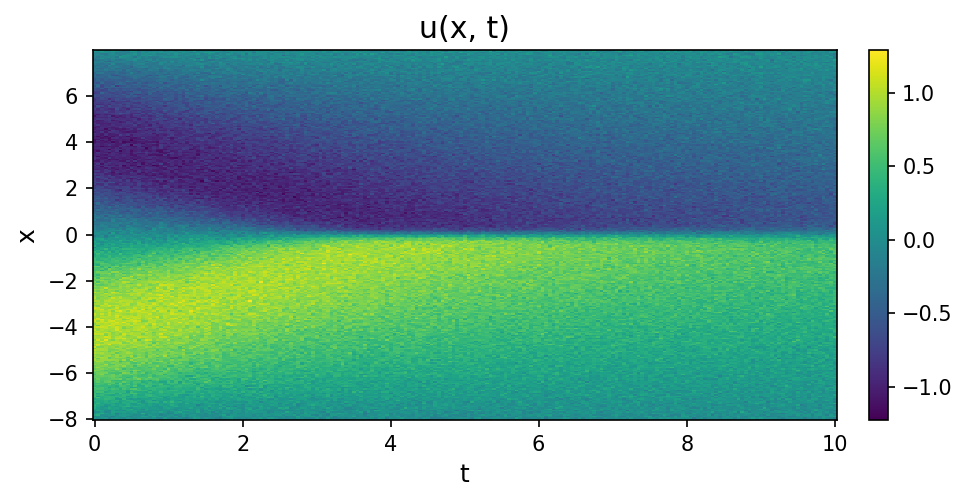

In [3]:
kd.viz.plots.plot_field(dataset)


## Differentiate the samples directly

Finite differences of a noisy field amplify the noise: at this level the
derivative columns carry little of the signal, and a search over them keeps
whatever fits the noise. SGA-PDE at the budget its Burgers recovery suite
validates on the clean field (100 generations, seed 42) returns
`u_t = 0.002134 u^2 x^3` here, a term with no derivative in it, after about
3 minutes.


In [4]:
direct = kd.Model(algorithm="sga", generations=100, seed=42, verbose=False).fit(dataset)
print(f"Discovered : {direct.result_.equation}")
print(f"Reference  : {dataset.ground_truth}")


Discovered : u_t = 0.002134*u**2*x**3
Reference  : u_t = -u * u_x + 0.1 * u_xx


## Fit DLGA

DLGA fits a neural network to the noisy samples and takes every derivative,
`u_t` included, from that network. `DLGAConfig.burgers_preset` locks the
length penalty validated for Burgers; `surrogate_max_epochs=50_000` is the
network's training budget, and `pop_size=50` with `generations=20` is the
genetic search budget the recovery suite runs at. The fit took about 158
minutes in this run.


In [5]:
model = kd.Model(
    algorithm="dlga",
    generations=20,
    config=kd.DLGAConfig.burgers_preset(pop_size=50, seed=0, surrogate_max_epochs=50_000),
    verbose=False,
).fit(dataset)
model


DLGA recovered expression has nmse=0.0258 and length=8 tokens. The default epsilon=1e-03 was tuned for raw-MSE-era fitness magnitudes; under the NMSE-era selector the length penalty contribution is smaller, so the GA may include small-coefficient noise terms. Truth structure is still recovered (see is_recovery_success superset match). To get a cleaner surface expression, raise DLGAConfig.epsilon to ~1e-2 to 5e-2 — see DLGAPlugin docstring for per-PDE recommendations.


Model(algorithm='dlga', fitted=True, best_expr='u_t = -0.9829*u*u_x - 0.002841*u*u_xxx + 1.184e-6*u_x*u_xxx**2 + 0.1039*u_xx', best_score=0.03381)

## Recovered law and the reference

DLGA prints the structure it selected; the fitted coefficients are on the
equation panel of the report below. In this run they are `-0.9829` for
`u u_x` (reference `-1`, relative error 1.7%) and `0.1039` for `u_xx`
(reference `0.1`, relative error 3.9%). Two further terms stayed in the
expression with coefficients far below those two, `-0.002841 u u_xxx` and
`1.184e-6 u_x u_xxx^2`; the fit's NMSE is 0.0258. The warning printed by the
fit says the same thing about them: at `epsilon=1e-3` the length penalty
leaves such small-coefficient terms in, and a larger `epsilon` shortens the
expression.


In [6]:
print(f"Discovered : {model.result_.equation}")
print(f"Reference  : {dataset.ground_truth}")


Discovered : u_t = -0.9829*u*u_x - 0.002841*u*u_xxx + 1.184e-6*u_x*u_xxx**2 + 0.1039*u_xx
Reference  : u_t = -u * u_x + 0.1 * u_xx


## The report

`model.report` renders every figure this fit supports and one HTML page that
embeds them: the convergence curve, the parity plot, the equation and its
tree, the coefficient bars, the residual figures, the noisy field next to the
field integrated from the discovered equation, the time slices, the error
heatmap, the PDE residual field, and DLGA's own diagnostics, including the
training curve of the network that supplied the derivatives. The page is
shown below; the same files are written to the output directory.


In [7]:
model.report("../out/noisy_burgers_walkthrough")


ReportResult(figures=[PosixPath('../out/noisy_burgers_walkthrough/convergence.svg'), PosixPath('../out/noisy_burgers_walkthrough/parity.svg'), PosixPath('../out/noisy_burgers_walkthrough/equation.svg'), PosixPath('../out/noisy_burgers_walkthrough/equation_tree.svg'), PosixPath('../out/noisy_burgers_walkthrough/residual.svg'), PosixPath('../out/noisy_burgers_walkthrough/coefficient_bar.svg'), PosixPath('../out/noisy_burgers_walkthrough/field_comparison.svg'), PosixPath('../out/noisy_burgers_walkthrough/pde_residual_field.svg'), PosixPath('../out/noisy_burgers_walkthrough/time_slices.svg'), PosixPath('../out/noisy_burgers_walkthrough/error_heatmap.svg'), PosixPath('../out/noisy_burgers_walkthrough/plugin_fitness_spread.svg'), PosixPath('../out/noisy_burgers_walkthrough/plugin_population_diversity.svg'), PosixPath('../out/noisy_burgers_walkthrough/plugin_complexity_evolution.svg'), PosixPath('../out/noisy_burgers_walkthrough/plugin_surrogate_training.svg')], data_files=[], report=PosixPath('../out/noisy_burgers_walkthrough/report.html'), warnings=['Domain note: this run fitted derivatives in an autograd / NN-smoothed domain. Forward time integration necessarily applies finite-difference spatial derivatives to the evolved states (the same D-007 stencils as the data pipeline; no autograd surrogate exists for integrator states). Integrating autograd-fitted coefficients with finite-difference derivatives is an inherent approximation of this plot: final_eval (fit quality in the autograd domain) and field-comparison metrics (physical recovery in the finite-difference domain) measure different things and may disagree on noisy data. This is expected, not a discovery error.'])

## Next steps

- [`kdv_walkthrough.ipynb`](kdv_walkthrough.ipynb): the same four calls on a
  clean field, with SGA-PDE differentiating the samples directly.
- [`08_dlga.py`](../08_dlga.py): DLGA on a synthetic Burgers field at a
  small budget, as a script.
- [`09_compare_algorithms.py`](../09_compare_algorithms.py): every algorithm
  on one dataset, scored with one ruler.
